# Lab 3: Monte Carlo Control for Blackjack

In this lab, We will implement **on‑policy first‑visit Monte Carlo control** (using an ε‑soft policy) for the Blackjack‑v1 environment from Gymnasium. You will train the agent for at least 500,000 episodes, visualise the learned state‑value function, compare the policy with basic Blackjack strategy, and experiment with different ε values and decay schedules.

**Learning Objectives**
- Understand experience‑based learning without a model
- Implement first‑visit MC control
- Handle the exploration problem with ε‑greedy policies
- Properly handle episode termination and time limits in Gymnasium
- Create 3D surface plots and learning curves

In [1]:
# ── Library imports ───────────────────────────────────────────────
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

## 1. Environment Setup

We use the `Blackjack‑v1` environment from Gymnasium. The state consists of:
- `player_sum` (int ∈ {4,…,21})
- `dealer_card` (int ∈ {1,…,10})
- `usable_ace` (bool)

Actions: 0 = STICK (stand), 1 = HIT.

We will only consider player sums ≥ 12 because below 12 the optimal action is always HIT.

In [2]:
env = gym.make('Blackjack-v1')

## 2. On‑policy first‑visit MC control (ε‑greedy)

We follow the algorithm from Sutton & Barto (Chapter 5). The Q‑values are stored in a dictionary mapping `(player_sum, dealer_card, usable_ace)` → numpy array of shape (2,).

The policy is ε‑greedy: with probability ε we pick a random action, otherwise the greedy action according to Q.

In [3]:
def mc_control_blackjack(env, num_episodes, epsilon_start=1.0, epsilon_end=0.1,
                          epsilon_decay=0.9, gamma=1.0):
    """
    On‑policy first‑visit MC control with decaying ε‑greedy.
    Returns:
        Q : dict mapping state → np.array([Q0, Q1])
        policy : dict mapping state → greedy action
        episode_returns : list of returns for each episode
    """
    # Q‑table: default to zeros for unseen states
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    returns_sum = defaultdict(lambda: np.zeros(env.action_space.n))
    returns_count = defaultdict(lambda: np.zeros(env.action_space.n, dtype=int))

    episode_returns = []
    epsilon = epsilon_start

    for i_episode in range(1, num_episodes + 1):
        # Decay epsilon (optional, if decay factor is used)
        if epsilon_decay:
            epsilon = max(epsilon_end, epsilon_start * (epsilon_decay ** i_episode))
        else:
            epsilon = epsilon_start   # constant epsilon

        # Generate an episode following ε‑greedy policy
        episode = []
        state, info = env.reset()
        done = False
        while not done:
            # Choose action
            if np.random.rand() < epsilon:
                action = env.action_space.sample()   # explore
            else:
                action = int(np.argmax(Q[state]))   # exploit

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode.append((state, action, reward))
            state = next_state

        # Store total return of this episode
        G_episode = sum(r for (_, _, r) in episode)
        episode_returns.append(G_episode)

        # First‑visit MC update (backward pass)
        visited = set()
        G = 0.0
        for (s, a, r) in reversed(episode):
            G = r + gamma * G
            if (s, a) not in visited:
                visited.add((s, a))
                returns_sum[s][a] += G
                returns_count[s][a] += 1
                Q[s][a] = returns_sum[s][a] / returns_count[s][a]

    # Extract greedy policy
    policy = {s: int(np.argmax(Q[s])) for s in Q.keys()}

    return Q, policy, episode_returns


## 3. Training

We train for 500,000 episodes. The initial ε starts high to encourage exploration and decays to a smaller final value. You can experiment with different settings.

In [4]:
NUM_EPISODES = 500_000
Q, policy, returns = mc_control_blackjack(env, NUM_EPISODES,
                                          epsilon_start=1.0,
                                          epsilon_end=0.1,
                                          epsilon_decay=0.9,
                                          gamma=1.0)

## 4. Learning Curve (Smoothed)

We plot the average return over episodes using a moving average to see how the agent's performance improves over time.

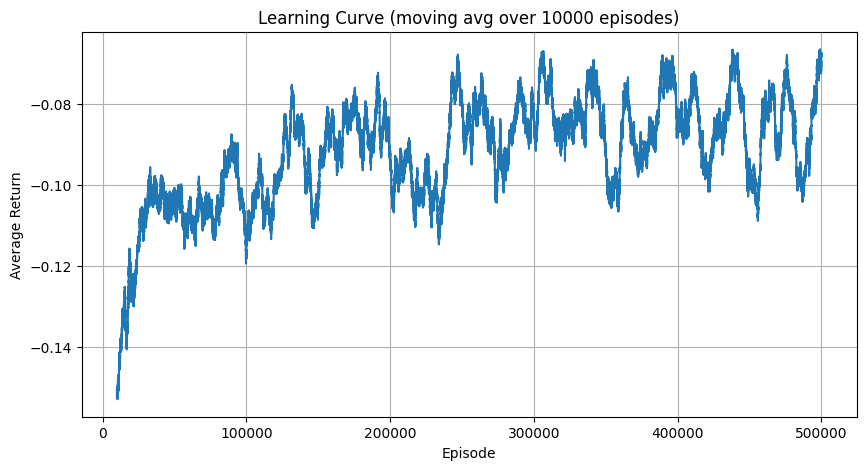

In [5]:
def moving_average(data, window):
    return np.convolve(data, np.ones(window)/window, mode='valid')

window = 10000   # averaging window
smoothed = moving_average(returns, window)

plt.figure(figsize=(10,5))
plt.plot(range(window, NUM_EPISODES+1), smoothed)
plt.xlabel('Episode')
plt.ylabel('Average Return')
plt.title(f'Learning Curve (moving avg over {window} episodes)')
plt.grid(True)
plt.show()

## 5. Value Function Visualisation (3D surfaces)

We extract the state‑value function V(s) = max_a Q(s,a) and plot it as a 3D surface for both `usable_ace` and `no usable_ace`. The axes are `player_sum` (12‑21) and `dealer_card` (1‑10).

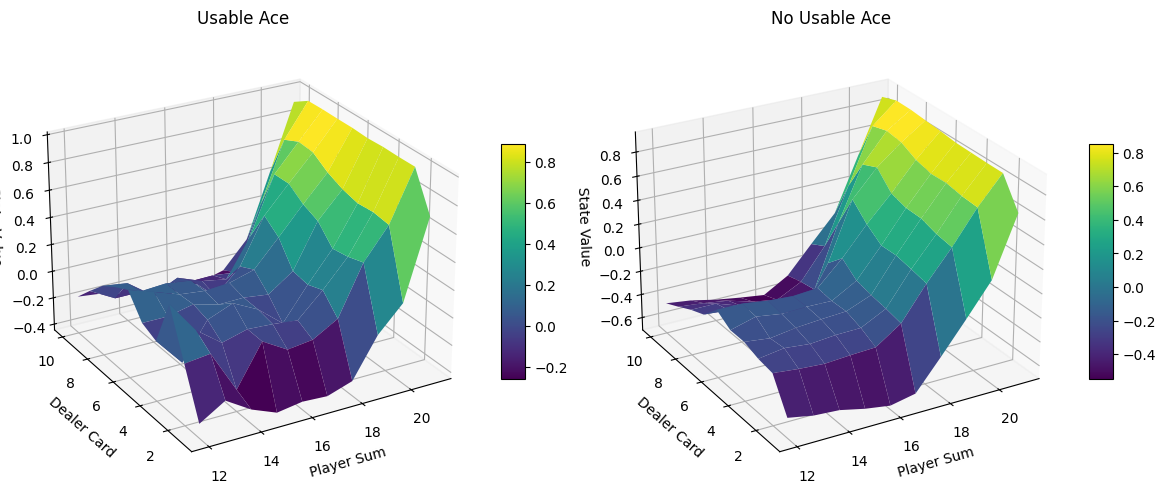

In [6]:
def prepare_surface(Q, usable_ace):
    """Create matrix for surface plot."""
    x_range = np.arange(12, 22)          # player sum 12..21
    y_range = np.arange(1, 11)            # dealer card 1..10
    X, Y = np.meshgrid(x_range, y_range)
    Z = np.zeros_like(X, dtype=float)
    for i, player in enumerate(x_range):
        for j, dealer in enumerate(y_range):
            s = (player, dealer, usable_ace)
            Z[j, i] = np.max(Q[s])   # max Q‑value = V(s)
    return X, Y, Z

fig = plt.figure(figsize=(12, 5))

# Usable ace
ax1 = fig.add_subplot(121, projection='3d')
X1, Y1, Z1 = prepare_surface(Q, True)
surf1 = ax1.plot_surface(X1, Y1, Z1, cmap='viridis', edgecolor='none')
ax1.set_xlabel('Player Sum')
ax1.set_ylabel('Dealer Card')
ax1.set_zlabel('State Value')
ax1.set_title('Usable Ace')
ax1.view_init(elev=25, azim=-120)
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

# No usable ace
ax2 = fig.add_subplot(122, projection='3d')
X2, Y2, Z2 = prepare_surface(Q, False)
surf2 = ax2.plot_surface(X2, Y2, Z2, cmap='viridis', edgecolor='none')
ax2.set_xlabel('Player Sum')
ax2.set_ylabel('Dealer Card')
ax2.set_zlabel('State Value')
ax2.set_title('No Usable Ace')
ax2.view_init(elev=25, azim=-120)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()

## 6. Policy Analysis – Comparison with Basic Strategy

We print the greedy policy for a selection of common Blackjack states and compare it with the well‑known "basic strategy" (which is close to optimal). For a quick reference:
- With a usable ace, you almost always HIT when the player sum ≤ 18.
- Hard totals: stand on 17+, hit on 12‑16 depending on dealer's upcard.

In [7]:
print("Greedy policy (0=STICK, 1=HIT) for selected states:\n")
print("  Player  Dealer  UsableAce  Action")
print("  ------  ------  ---------  ------")
for player in [20, 16, 12, 18, 15]:
    for dealer in [6, 10, 2, 9, 5]:
        for ace in [False, True]:
            s = (player, dealer, ace)
            if s in policy:
                act = policy[s]
                print(f"  {player:>6}  {dealer:>6}  {str(ace):>9}  {'STICK' if act==0 else 'HIT'}")


Greedy policy (0=STICK, 1=HIT) for selected states:

  Player  Dealer  UsableAce  Action
  ------  ------  ---------  ------
      20       6      False  STICK
      20       6       True  STICK
      20      10      False  STICK
      20      10       True  STICK
      20       2      False  STICK
      20       2       True  STICK
      20       9      False  STICK
      20       9       True  STICK
      20       5      False  STICK
      20       5       True  STICK
      16       6      False  STICK
      16       6       True  HIT
      16      10      False  HIT
      16      10       True  HIT
      16       2      False  STICK
      16       2       True  HIT
      16       9      False  STICK
      16       9       True  HIT
      16       5      False  STICK
      16       5       True  HIT
      12       6      False  STICK
      12       6       True  HIT
      12      10      False  HIT
      12      10       True  HIT
      12       2      False  HIT
      12       2    

## 7. Experimenting with different ε values

We run the same MC control with different constant ε values (no decay) and compare the final win rates against a baseline random policy. (For brevity, we train for only 100,000 episodes.)

In [8]:
def evaluate_policy(Q, env, num_eval=50000):
    """Evaluate the greedy policy derived from Q (ε=0)."""
    wins = 0
    for _ in range(num_eval):
        state, _ = env.reset()
        done = False
        while not done:
            action = int(np.argmax(Q[state]))   # always greedy
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        if reward > 0:
            wins += 1
    return wins / num_eval

eps_vals = [1.0, 0.5, 0.1, 0.01, 0.001]
results = {}
for ep in eps_vals:
    Q_temp, _, _ = mc_control_blackjack(env, 100000, epsilon_start=ep,
                                        epsilon_end=ep, epsilon_decay=None)
    win_rate = evaluate_policy(Q_temp, env, 20000)
    results[ep] = win_rate
    print(f"ε = {ep:.3f}  ->  win rate (greedy) = {win_rate:.3f}")

ε = 1.000  ->  win rate (greedy) = 0.413
ε = 0.500  ->  win rate (greedy) = 0.427
ε = 0.100  ->  win rate (greedy) = 0.423
ε = 0.010  ->  win rate (greedy) = 0.408
ε = 0.001  ->  win rate (greedy) = 0.395


## 8. ε‑decay schedule experiment

We compare constant ε = 0.1 with a schedule that decays from 1.0 to 0.1 over time. We expect the decay schedule to lead to faster learning or higher final performance.

Constant ε=0.1 : win rate = 0.433
Decay 1.0→0.1 : win rate = 0.430


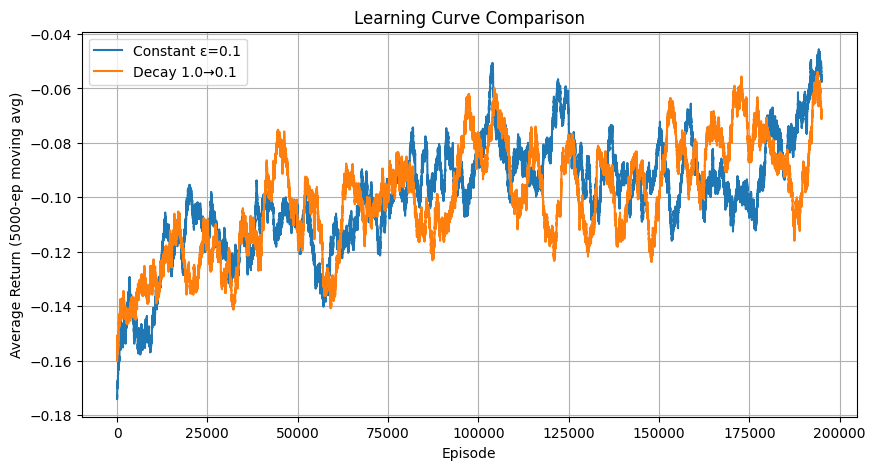

In [9]:
# Compare constant ε=0.1 vs decay (1.0 → 0.1)
Q_const, _, ret_const = mc_control_blackjack(env, 200000, epsilon_start=0.1,
                                               epsilon_end=0.1, epsilon_decay=None)
Q_decay, _, ret_decay = mc_control_blackjack(env, 200000, epsilon_start=1.0,
                                              epsilon_end=0.1, epsilon_decay=0.9)

win_const = evaluate_policy(Q_const, env, 20000)
win_decay = evaluate_policy(Q_decay, env, 20000)
print(f"Constant ε=0.1 : win rate = {win_const:.3f}")
print(f"Decay 1.0→0.1 : win rate = {win_decay:.3f}")

# Smoothed learning curves
window2 = 5000
plt.figure(figsize=(10,5))
plt.plot(moving_average(ret_const, window2), label='Constant ε=0.1')
plt.plot(moving_average(ret_decay, window2), label='Decay 1.0→0.1')
plt.xlabel('Episode')
plt.ylabel(f'Average Return ({window2}-ep moving avg)')
plt.title('Learning Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

## 9. Conclusion

In this lab We have:
- Implemented first‑visit on‑policy MC control for Blackjack.
- Visualised the learned value function as 3D surfaces.
- Compared the learned policy with basic Blackjack strategy.
- Analysed the effect of ε on exploration and final performance.
- Demonstrated that a decaying ε schedule can improve learning.

These are the same principles that underpin many real‑world reinforcement learning applications: we learn purely from experience, without a model of the environment.